In [ ]:
path= r"/content/imdb_top_1000 movies.xlsx"
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import one_hot# is used to convert text into a list of integers( basic form of tokenization)Each word is hashed to an integer between 1 and vocab_size[200,300,200]
from tensorflow.keras.preprocessing.sequence import pad_sequences#It ensures that all sequences (e.g., tokenized sentences or reviews) in a dataset have the same length by:

In [ ]:
#df = pd.read_excel(path)#Reads an Excel file (.xls or .xlsx) from the specified path
df = pd.read_excel(path,nrows=100)# consider 100 data sets instead of entire dataset

In [ ]:
df.head (5)#df refers to a DataFrame, which is a 2D labeled data structure (like a table).returns the first 5 rows of the DataFrame


,Series_Title,Genre,IMDB_Rating,Overview,Meta_score,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,sentiment,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,sentiment.1
0,The Shawshank Redemption,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,NaN,NaN,NaN,NaN,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,The Godfather,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,NaN,NaN,NaN,NaN,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,The Dark Knight,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,NaN,NaN,NaN,NaN,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,The Godfather: Part II,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,NaN,NaN,NaN,NaN,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12 Angry Men,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,NaN,NaN,NaN,NaN,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convert sentiments from categorical sentences to numeral values

In [ ]:
df["sentiment"].replace({"positive" :1, "negative" :0},inplace=True)# replacing sentiments with numericals
df.head (5)

NameError: name 'df' is not defined

In [ ]:
x = np.array(df["Overview"].values)
y = np.array(df["sentiment"].values)
# Filter out rows where 'sentiment' is not 0 or 1
valid_indices = np.where(np.isin(y, [0, 1]))
x = x[valid_indices]
y = y[valid_indices]

In [ ]:
x_filtered=[]# initialized an empty list
for Overview in x:
  Overview=Overview.lower()# lowercasing the sentense
  x_filtered.append (Overview)

  #for i in Overview: # remove punctuation from sentence
   # punc = '''!()-[]{};:' "\,<>./?@#$%^&*_~'''
   #  x_filtered.append (Overview)
     # print ( x_filtered)

One hot encoding -converting

In [ ]:
vocabulary_size= 5000 # each word is represened as a vector array of 5000
one_hot_encoded= [one_hot(Overview,vocabulary_size) for Overview in x_filtered]#maps each word into a uniques interge based on hashing function, contained by vocabulary size
print (one_hot_encoded)

[[1540, 735, 3617, 3429, 1307, 2989, 4202, 3986, 557, 3540, 4850, 2429, 503, 3705, 3468, 3409, 3986, 2497, 2640], [2299, 3790, 2647, 3535, 4636, 3790, 415, 929, 3198, 2429, 3161, 334, 3790, 2745, 3986, 442, 4280, 4447, 4163, 2511, 3986, 3790, 1643, 2212, 2429, 4511, 2478, 3986, 653, 2566, 4685, 1883, 498], [3790, 4019, 1896, 2429, 2933, 3986, 2398, 1740, 395, 1837, 2919, 2608, 3086, 2592, 4281, 4628, 653, 3282, 184, 1132, 2429, 899, 653, 4409, 334, 3790, 4643, 1348, 4321], [2989, 906, 4286, 520, 4685, 2817, 2989, 2980, 3986, 4247, 4323, 3158, 653, 4167, 4685, 2399, 3790, 585], [1188, 2429, 1990, 110, 3790, 1954, 3986, 3617, 3499, 1864, 613, 4685, 1854, 653, 1458, 2311, 3302, 2429, 843, 4636, 4387, 4147, 4596, 1739, 4572, 3790, 2511, 2563], [3790, 3935, 3986, 1540, 1302, 3311, 2989, 4610, 2989, 2588, 2429, 653, 3257, 2429, 2989, 1178, 3986, 1763, 3647, 4456, 395, 2734, 2824, 3986, 2290, 2429, 3705], [395, 1031, 515, 351, 4873, 1954, 2984, 3082, 1397, 1668, 3156, 2968, 3073, 2471, 94, 65

Padding- Each encoded sentence has a max lenght of 500


In [ ]:
max_lenght= 500
x_padded= pad_sequences(one_hot_encoded,max_lenght,padding="post")

Split data set for training


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_padded, y, test_size=0.2)# using 20% of dataset for training
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

Build LSTM

In [ ]:
model = Sequential()
embedding_vecor_length = 32 #each word will be represented as a 32-dimensional vector.
model.add(Embedding(vocabulary_size, embedding_vecor_length, input_length=max_lenght))
model.add(LSTM(100))#adds and LSTM layer with 100 memory units ( 100 hidden units) tolearn long term dependencies
model.add(Dense(1, activation='sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Train the Model


In [ ]:
adam = optimizers.Adam(learning_rate=0.001)# gradient descent optimizer can be adjusted

model.compile(adam, loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3, batch_size=64)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4286 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5714 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step - accuracy: 0.5714 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.6947


Evaluate the model

1/1 - 0s - 119ms/step - accuracy: 0.5000 - loss: 0.6947
0.5


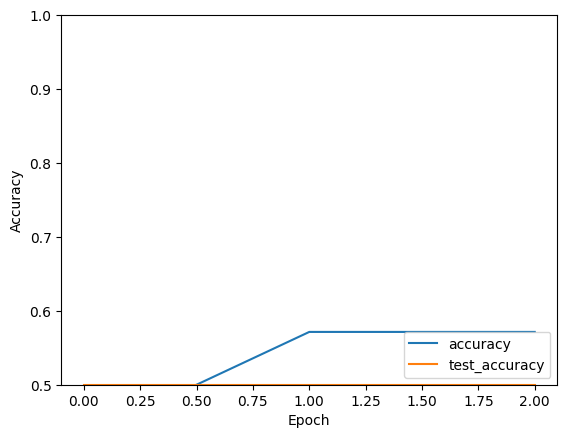

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'test_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(test_acc)

In [ ]:
score=model.evaluate(x_test,y_test,verbose=1)
print("Test Score:",score[0])
print("Test Accuracy:",score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5000 - loss: 0.6947
Test Score: 0.694743275642395
Test Accuracy: 0.5


In [ ]:
model.save('imdb_sentiment.analysis.keras')#save atrained model

In [ ]:
from keras.models import load_model# restores a saved model
trained_model=load_model('imdb_sentiment.analysis.keras')

Test teh model

In [ ]:
def get_sentiment(sentence: str, model):
    if not isinstance(sentence, str):
        raise Exception("Input needs to be of type 'str' ")

    # filtering the sentence
    sentence = sentence.lower()

    # You might want to re-add punctuation removal here if needed,
    # but make sure it matches your training preprocessing.
    # punc = '''!()-[]{};:'"\, <>./?@#$%^&*_~'''
    # for word in sentence:
    #     if word in punc:
    #         sentence = sentence.replace(word, " ")

    # Preprocess the input sentence to match the training data
    # Assuming you used one_hot and pad_sequences for training
    vocabulary_size = 5000 # Make sure this matches the training vocabulary size
    max_lenght = 500     # Make sure this matches the training max_length
    one_hot_encoded = [one_hot(sentence, vocabulary_size)]
    padded_sentence = pad_sequences(one_hot_encoded, max_lenght, padding="post")


    predicted = model.predict(padded_sentence)[0][0] # Access the first prediction

    sentiment = 1 if predicted > 0.5 else 0

    if sentiment == 1:
        print("Positive")
    else:
        print("Negative")

    return sentiment

# Load the model outside the function
from keras.models import load_model
trained_model = load_model("/content/imdb_sentiment.analysis.keras")

# Test the model with the function
get_sentiment("That movie was really good!", trained_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Positive


1